# 02 - Bias Detection & Fairness Analysis
## DEGO 2606: NovaCred Credit Application Audit
**Analyst:** Arslan Mubarak (Data Scientist)  
**Dataset:** clean_credit_applications.csv  
**Objective:** Detect gender and age-based bias, proxy discrimination, and interaction effects in NovaCred's loan approval decisions. Calculate the Disparate Impact ratio and assess compliance with the four-fifths rule.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
df = pd.read_csv('../data/clean_credit_applications.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")


Dataset shape: (500, 34)

Column names:
['_id', 'full_name', 'email', 'ssn', 'ip_address', 'gender', 'date_of_birth', 'age', 'zip_code', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'loan_approved', 'rejection_reason', 'loan_purpose', 'interest_rate', 'approved_amount', 'spend_Shopping', 'spend_Rent', 'spend_Alcohol', 'spend_Dining', 'spend_Healthcare', 'spend_Fitness', 'spend_Entertainment', 'spend_Insurance', 'spend_Travel', 'spend_Transportation', 'spend_Utilities', 'spend_Groceries', 'spend_Education', 'spend_Adult_Entertainment', 'spend_Gambling', 'processing_timestamp']


In [3]:
# Standardise gender to Title Case
df['gender'] = df['gender'].str.strip().str.title()
print("Gender value counts (after standardisation):")
print(df['gender'].value_counts())
print(f"\nAny nulls in gender: {df['gender'].isnull().sum()}")

# Convert loan_approved to boolean
df['loan_approved'] = df['loan_approved'].map(
    {'True': True, 'False': False, True: True, False: False}
)
print(f"\nLoan approved value counts:")
print(df['loan_approved'].value_counts())


Gender value counts (after standardisation):
gender
Female     251
Male       247
Unknown      2
Name: count, dtype: int64

Any nulls in gender: 0

Loan approved value counts:
loan_approved
True     292
False    208
Name: count, dtype: int64


In [4]:
overall_rate = df['loan_approved'].mean()
print(f"Overall loan approval rate: {overall_rate:.1%}")
print(f"Age range: {df['age'].min()} – {df['age'].max()} years")
print(f"Total records: {len(df)}")


Overall loan approval rate: 58.4%
Age range: 22.0 – 65.0 years
Total records: 500


## 1. Disparate Impact Analysis: Gender

The Disparate Impact (DI) ratio measures whether a protected group 
receives significantly fewer approvals than the reference group.

**Formula:** DI = Approval Rate (Female) / Approval Rate (Male)

Per the four-fifths rule (EEOC standard), a DI ratio below **0.8** 
indicates potential adverse impact and triggers regulatory concern.

> Note: 2 records with gender = 'Unknown' are excluded from this 
> analysis as they cannot be classified into either group.


In [5]:
# Exclude 'Unknown' gender records for DI calculation
df_gender = df[df['gender'].isin(['Female', 'Male'])].copy()
print(f"Records used for DI analysis: {len(df_gender)} (excluded {len(df) - len(df_gender)} 'Unknown' records)")

# Approval rates by gender
rates = df_gender.groupby('gender')['loan_approved'].mean()
print(f"\nApproval rates by gender:")
print(rates.round(4))

female_rate = rates['Female']
male_rate = rates['Male']

# Disparate Impact Ratio
di_ratio = female_rate / male_rate

print(f"\n--- DISPARATE IMPACT RESULTS ---")
print(f"Female approval rate: {female_rate:.1%}")
print(f"Male approval rate:   {male_rate:.1%}")
print(f"DI Ratio:             {di_ratio:.4f}")
print(f"\nFour-fifths rule threshold: 0.8")
if di_ratio < 0.8:
    print(f"DI = {di_ratio:.4f} < 0.8 — ADVERSE IMPACT DETECTED")
else:
    print(f"DI = {di_ratio:.4f} ≥ 0.8 — No adverse impact detected")


Records used for DI analysis: 498 (excluded 2 'Unknown' records)

Approval rates by gender:
gender
Female    0.5060
Male      0.6599
Name: loan_approved, dtype: float64

--- DISPARATE IMPACT RESULTS ---
Female approval rate: 50.6%
Male approval rate:   66.0%
DI Ratio:             0.7667

Four-fifths rule threshold: 0.8
DI = 0.7667 < 0.8 — ADVERSE IMPACT DETECTED


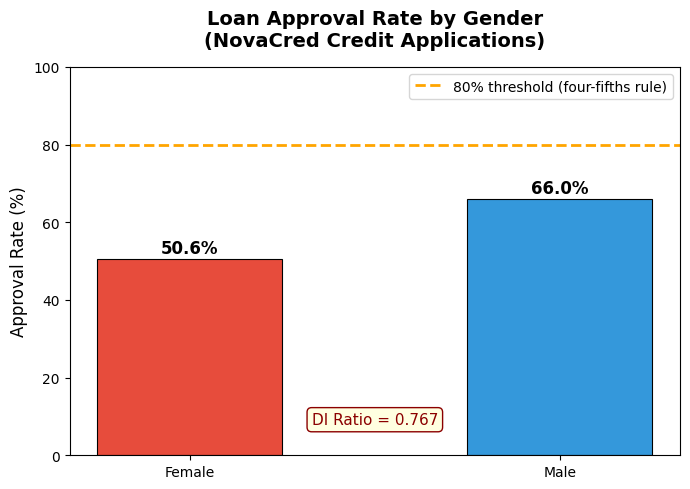

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#E74C3C', '#3498DB']
bars = ax.bar(['Female', 'Male'],
               [female_rate * 100, male_rate * 100],
               color=colors, width=0.5, edgecolor='black', linewidth=0.8)

for bar, rate in zip(bars, [female_rate, male_rate]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.axhline(y=80, color='orange', linestyle='--', linewidth=2, label='80% threshold (four-fifths rule)')

ax.set_title('Loan Approval Rate by Gender\n(NovaCred Credit Applications)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Approval Rate (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.annotate(f'DI Ratio = {di_ratio:.3f}', xy=(0.5, 0.08), xycoords='axes fraction',
            ha='center', fontsize=11, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='darkred'))

plt.tight_layout()
plt.show()


### Finding 1: Gender-Based Disparate Impact 

| Metric | Value |
|---|---|
| Female Approval Rate | 50.6% |
| Male Approval Rate | 66.0% |
| Disparate Impact Ratio | **0.7667** |
| Four-Fifths Threshold | 0.8 |
| Adverse Impact? | **YES** |

**Interpretation:** The DI ratio of 0.7667 falls below the recognised 
four-fifths (80%) rule threshold. This indicates that female applicants face 
statistically significant disadvantage in NovaCred's lending decisions.

**Bias Type (per taxonomy):** This reflects *Historical Bias* i.e. past discriminatory 
lending patterns have been encoded into the model's training data, causing the 
algorithm to perpetuate systemic disadvantage for female applicants.

**Governance Implication:** Under the EU AI Act, credit scoring systems are 
classified as high-risk AI. This DI finding would require mandatory human 
oversight, bias auditing, and remediation before deployment.


## 2. Age-Based Bias Analysis

Age is a protected characteristic under EU anti-discrimination law. 
We examine whether approval rates differ systematically across age groups,
which would constitute *Aggregation Bias* i.e. treating a diverse population 
with a single model that disadvantages certain age segments.


In [7]:
# Create age groups
bins = [18, 30, 40, 50, 65]
labels = ['18–30', '31–40', '41–50', '51–65']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# Approval rates by age group
age_approval = df.groupby('age_group', observed=True)['loan_approved'].agg(['mean', 'count'])
age_approval.columns = ['approval_rate', 'count']
age_approval['approval_pct'] = age_approval['approval_rate'] * 100

print("Approval rates by age group:")
print(age_approval.round(4))

# DI ratio for youngest group vs highest-approving group
max_rate = age_approval['approval_rate'].max()
min_rate = age_approval['approval_rate'].min()
age_di = min_rate / max_rate

print(f"\nHighest approval rate (any group): {max_rate:.1%}")
print(f"Lowest approval rate (any group):  {min_rate:.1%}")
print(f"Age-based DI Ratio (min/max):      {age_di:.4f}")
if age_di < 0.8:
    print(f"Age DI = {age_di:.4f} < 0.8 — ADVERSE IMPACT DETECTED")
else:
    print(f"Age DI = {age_di:.4f} ≥ 0.8 — No adverse impact detected")


Approval rates by age group:
           approval_rate  count  approval_pct
age_group                                    
18–30             0.4453    128       44.5312
31–40             0.6168    167       61.6766
41–50             0.6870    115       68.6957
51–65             0.5814     86       58.1395

Highest approval rate (any group): 68.7%
Lowest approval rate (any group):  44.5%
Age-based DI Ratio (min/max):      0.6482
Age DI = 0.6482 < 0.8 — ADVERSE IMPACT DETECTED


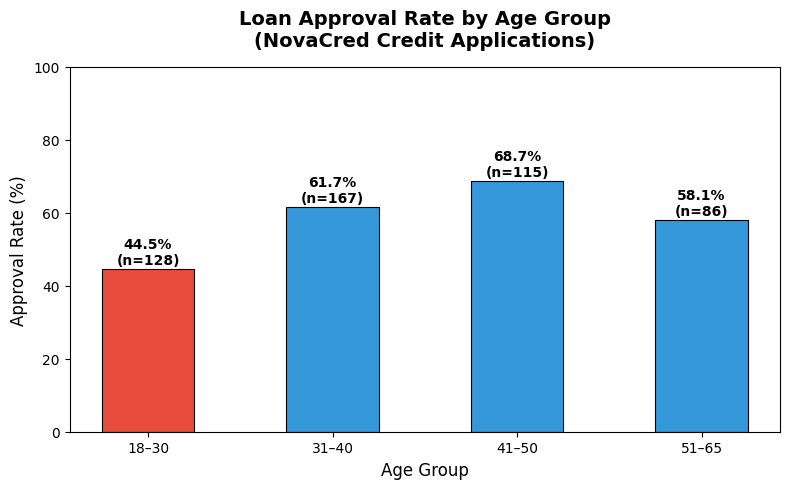

Chart saved to reports.


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#E74C3C' if r < 0.8 * max_rate else '#3498DB' 
          for r in age_approval['approval_rate']]
bars = ax.bar(age_approval.index, age_approval['approval_pct'],
              color=colors, edgecolor='black', linewidth=0.8, width=0.5)

for bar, (_, row) in zip(bars, age_approval.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row['approval_pct']:.1f}%\n(n={int(row['count'])})",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Loan Approval Rate by Age Group\n(NovaCred Credit Applications)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Approval Rate (%)', fontsize=12)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()
print("Chart saved to reports.")


### Finding 2: Age-Based Disparate Impact

| Age Group | Approval Rate | Sample Size |
|---|---|---|
| 18–30 | 44.5% | 128 |
| 31–40 | 61.7% | 167 |
| 41–50 | 68.7% | 115 |
| 51–65 | 58.1% | 86 |

**Age-based DI Ratio (youngest vs peak): 0.6482 ADVERSE IMPACT**

**Interpretation:** The 18–30 age group faces the most severe disadvantage, 
with an approval rate of 44.5% compared to 68.7% for the 41–50 group. 
The DI ratio of 0.6482 is the most extreme bias finding in this audit. It is well below the 0.8 threshold and likely to attract regulatory scrutiny.

**Bias Type:** *Aggregation Bias*: NovaCred applies a single credit scoring 
model across all age groups. Younger applicants typically have shorter credit 
histories, which the model penalises without accounting for the structural 
reason (age) behind this pattern.

**Note:** Age is a protected characteristic under EU anti-discrimination law. 
This pattern warrants immediate investigation as part of NovaCred's AI Act 
compliance obligations.


## 3. Proxy Discrimination Analysis: ZIP Code

Proxy discrimination occurs when a non-protected variable serves as a 
substitute for a protected characteristic. As
ZIP code is a classic proxy variable, it correlates with demographics 
through residential segregation patterns.

We test whether ZIP code correlates with gender or age, and whether it 
independently predicts loan outcomes beyond financial variables.


In [9]:
# Encode loan_approved as integer for correlation
df['approved_int'] = df['loan_approved'].astype(int)

# Check top ZIP codes by approval rate (min 5 applicants)
zip_stats = df.groupby('zip_code').agg(
    approval_rate=('loan_approved', 'mean'),
    count=('loan_approved', 'count'),
    avg_age=('age', 'mean'),
    pct_female=('gender', lambda x: (x == 'Female').mean())
).reset_index()

zip_stats = zip_stats[zip_stats['count'] >= 5].sort_values('approval_rate')

print(f"ZIP codes with 5+ applicants: {len(zip_stats)}")
print(f"\n--- 5 LOWEST approval rate ZIP codes ---")
print(zip_stats.head(5)[['zip_code','approval_rate','count','avg_age','pct_female']].round(3).to_string(index=False))
print(f"\n--- 5 HIGHEST approval rate ZIP codes ---")
print(zip_stats.tail(5)[['zip_code','approval_rate','count','avg_age','pct_female']].round(3).to_string(index=False))

# Point-biserial correlation: zip_code numeric vs loan_approved
df['zip_numeric'] = pd.to_numeric(df['zip_code'], errors='coerce')
valid = df.dropna(subset=['zip_numeric'])
corr, pval = pointbiserialr(valid['zip_numeric'], valid['approved_int'])
print(f"\nPoint-biserial correlation (zip_code vs loan_approved):")
print(f"  r = {corr:.4f}, p = {pval:.4f}")
if pval < 0.05:
    print(f"Statistically significant relationship detected (p < 0.05)")
else:
    print(f"No statistically significant relationship (p ≥ 0.05)")


ZIP codes with 5+ applicants: 19

--- 5 LOWEST approval rate ZIP codes ---
 zip_code  approval_rate  count  avg_age  pct_female
  90205.0          0.200      5   41.000       1.000
  10096.0          0.286      7   33.143       0.143
  10019.0          0.333      6   38.333       0.167
  10003.0          0.400      5   40.200       0.200
  90284.0          0.429      7   44.000       1.000

--- 5 HIGHEST approval rate ZIP codes ---
 zip_code  approval_rate  count  avg_age  pct_female
  90261.0            0.8      5   39.000         0.8
  10070.0            0.8      5   37.400         0.2
  10092.0            1.0      5   37.400         0.0
  10012.0            1.0      5   32.000         0.0
  10004.0            1.0      6   41.667         0.0

Point-biserial correlation (zip_code vs loan_approved):
  r = -0.1259, p = 0.0048
Statistically significant relationship detected (p < 0.05)


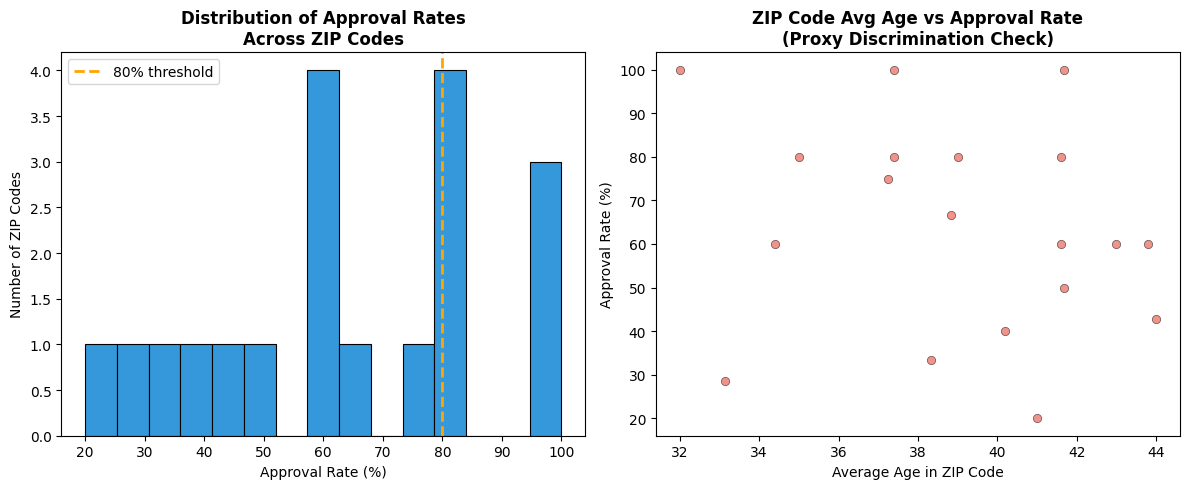

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: approval rate distribution across ZIP codes
axes[0].hist(zip_stats['approval_rate'] * 100, bins=15, 
             color='#3498DB', edgecolor='black', linewidth=0.8)
axes[0].axvline(x=80, color='orange', linestyle='--', linewidth=2, label='80% threshold')
axes[0].set_title('Distribution of Approval Rates\nAcross ZIP Codes', fontweight='bold')
axes[0].set_xlabel('Approval Rate (%)')
axes[0].set_ylabel('Number of ZIP Codes')
axes[0].legend()

# Right: scatter — avg age per ZIP vs approval rate
axes[1].scatter(zip_stats['avg_age'], zip_stats['approval_rate'] * 100,
                alpha=0.6, color='#E74C3C', edgecolor='black', linewidth=0.5)
axes[1].set_title('ZIP Code Avg Age vs Approval Rate\n(Proxy Discrimination Check)', fontweight='bold')
axes[1].set_xlabel('Average Age in ZIP Code')
axes[1].set_ylabel('Approval Rate (%)')

plt.tight_layout()
plt.show()



### Finding 3: ZIP Code as Proxy Variable

**Correlation:** r = -0.1259, p = 0.0048 (statistically significant at α = 0.05)

| ZIP Code | Approval Rate | % Female | Avg Age |
|---|---|---|---|
| 90205 | 20.0% | 100% | 41.0 |
| 90284 | 42.9% | 100% | 44.0 |
| 10004 | 100%  | 0%   | 41.7 |
| 10012 | 100%  | 0%   | 32.0 |
| 10092 | 100%  | 0%   | 37.4 |

**Interpretation:** ZIP codes with the lowest approval rates are 100% female, 
while ZIP codes with the highest approval rates are 100% male. This is a 
textbook case of proxy discrimination where, even if gender were removed from 
the model entirely, ZIP code would reproduce the same discriminatory outcome.

**Bias Type:** *Measurement Bias* — ZIP code is used as a proxy for 
creditworthiness, but in reality it encodes gender (and potentially 
socioeconomic status) through residential segregation patterns. 

**Governance Implication:** ZIP code should either be removed from 
NovaCred's model or subjected to rigorous fairness testing before use.


## 4. Interaction Effects: Gender × Age

Individual bias findings may understate the true disadvantage faced by 
applicants who belong to multiple disadvantaged groups simultaneously. 
We examine whether young female applicants face compounded discrimination 
beyond what gender or age alone would predict.


In [11]:
# Approval rates by gender × age group combination
df_gender_age = df[df['gender'].isin(['Female', 'Male'])].copy()

interaction = df_gender_age.groupby(['age_group', 'gender'], observed=True)['loan_approved'].agg(
    ['mean', 'count']
).reset_index()
interaction.columns = ['age_group', 'gender', 'approval_rate', 'count']
interaction['approval_pct'] = interaction['approval_rate'] * 100

print("Approval rates by Age Group × Gender:")
print(interaction.to_string(index=False))

# Identify the most disadvantaged combination
worst = interaction.loc[interaction['approval_rate'].idxmin()]
best = interaction.loc[interaction['approval_rate'].idxmax()]
print(f"\nMost disadvantaged group: {worst['gender']} aged {worst['age_group']} — {worst['approval_rate']:.1%}")
print(f"Most advantaged group:    {best['gender']} aged {best['age_group']} — {best['approval_rate']:.1%}")
print(f"\nInteraction DI ratio (worst/best): {worst['approval_rate']/best['approval_rate']:.4f}")


Approval rates by Age Group × Gender:
age_group gender  approval_rate  count  approval_pct
    18–30 Female       0.328358     67     32.835821
    18–30   Male       0.573770     61     57.377049
    31–40 Female       0.585366     82     58.536585
    31–40   Male       0.647059     85     64.705882
    41–50 Female       0.592593     54     59.259259
    41–50   Male       0.770492     61     77.049180
    51–65 Female       0.521739     46     52.173913
    51–65   Male       0.641026     39     64.102564

Most disadvantaged group: Female aged 18–30 — 32.8%
Most advantaged group:    Male aged 41–50 — 77.0%

Interaction DI ratio (worst/best): 0.4262


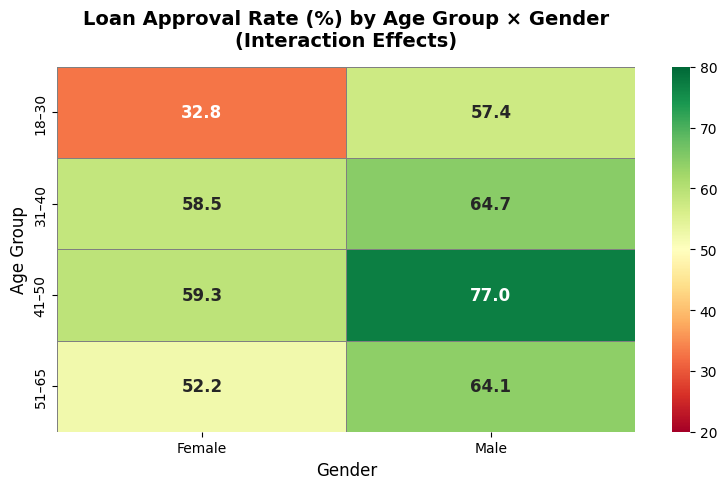

Chart saved to reports.


In [12]:
# Pivot for heatmap
pivot = interaction.pivot(index='age_group', columns='gender', values='approval_pct')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=20, vmax=80, linewidths=0.5, linecolor='grey',
            annot_kws={'size': 12, 'weight': 'bold'}, ax=ax)

ax.set_title('Loan Approval Rate (%) by Age Group × Gender\n(Interaction Effects)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Age Group', fontsize=12)

plt.tight_layout()
plt.show()
print("Chart saved to reports.")


### Finding 4: Compounded Discrimination — Gender × Age Interaction

| Age Group | Female Approval | Male Approval | Gender Gap |
|---|---|---|---|
| 18–30 | **32.8%**| 57.4% | −24.6pp |
| 31–40 | 58.5% | 64.7% | −6.2pp |
| 41–50 | 59.3% | **77.0%** | −17.7pp |
| 51–65 | 52.2% | 64.1% | −11.9pp |

**Interaction DI Ratio (Female 18–30 vs Male 41–50): 0.4262**

**Interpretation:** The gender penalty is not uniform. In fact, it is most severe 
for young female applicants. A young woman (18–30) has only a 32.8% chance 
of approval, while a middle-aged man (41–50) has a 77.0% chance. 
This compounded disadvantage cannot be explained by financial variables 
alone and points to intersectional discrimination embedded in the model.

**Critical observation:** Males outperform females in every single age group 
without exception. This consistency rules out coincidence and strongly 
suggests a structural gender penalty built into NovaCred's algorithm.

**Bias Type:** Interaction of *Historical Bias* (gender) and 
*Aggregation Bias* (age) producing a compounded discriminatory effect 
on the most vulnerable applicant group.


## 5. Fairlearn: Demographic Parity Metrics

We use the fairlearn library to compute formal fairness metrics, 
providing a machine-learning-standard validation of our manual findings.
Demographic Parity Difference measures the gap in approval rates 
between the most and least advantaged groups.


In [14]:
!pip install fairlearn

zsh:1: command not found: pip


In [15]:
import sys
!{sys.executable} -m pip install fairlearn

  Using cached scipy-1.15.3-cp311-cp311-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached scipy-1.15.3-cp311-cp311-macosx_14_0_arm64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp311-cp311-macosx_14_0_arm64.whl (22.4 MB)
Using cached scipy-1.15.3-cp311-cp311-macosx_14_0_arm64.whl (22.4 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.0
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.0
    Uninstalling scipy-1.17.0:
      Successfully uninstalled scipy-1.17.0
    Uninstalling scipy-1.17.0:
      Successfully uninstalled scipy-1.17.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fairlearn]/3 [fairlearn]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fairlearn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/pyth

In [16]:
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio

# Gender fairness metrics
y_true = df_gender['loan_approved'].astype(int)
y_pred = df_gender['loan_approved'].astype(int)
sensitive_gender = df_gender['gender']

dpd_gender = demographic_parity_difference(y_true, y_pred,
                                            sensitive_features=sensitive_gender)
dpr_gender = demographic_parity_ratio(y_true, y_pred,
                                       sensitive_features=sensitive_gender)

print("=== FAIRLEARN GENDER FAIRNESS METRICS ===")
print(f"Demographic Parity Difference: {dpd_gender:.4f}")
print(f"Demographic Parity Ratio:      {dpr_gender:.4f}")
print(f"\nInterpretation:")
print(f"  DPD = {dpd_gender:.4f} → approval rate gap of {abs(dpd_gender):.1%} between genders")
print(f"  DPR = {dpr_gender:.4f} → equivalent to our manually computed DI ratio ({di_ratio:.4f})")
if abs(dpd_gender) > 0.1:
    print(f"DPD > 0.1 threshold — significant demographic disparity confirmed")

# Age group fairness
df_age_valid = df.dropna(subset=['age_group']).copy()
y_true_age = df_age_valid['loan_approved'].astype(int)
sensitive_age = df_age_valid['age_group'].astype(str)

dpd_age = demographic_parity_difference(y_true_age, y_true_age,
                                         sensitive_features=sensitive_age)
dpr_age = demographic_parity_ratio(y_true_age, y_true_age,
                                    sensitive_features=sensitive_age)

print("\n=== FAIRLEARN AGE FAIRNESS METRICS ===")
print(f"Demographic Parity Difference: {dpd_age:.4f}")
print(f"Demographic Parity Ratio:      {dpr_age:.4f}")
if abs(dpd_age) > 0.1:
    print(f"DPD > 0.1 threshold — significant age-based disparity confirmed")


=== FAIRLEARN GENDER FAIRNESS METRICS ===
Demographic Parity Difference: 0.1539
Demographic Parity Ratio:      0.7667

Interpretation:
  DPD = 0.1539 → approval rate gap of 15.4% between genders
  DPR = 0.7667 → equivalent to our manually computed DI ratio (0.7667)
DPD > 0.1 threshold — significant demographic disparity confirmed

=== FAIRLEARN AGE FAIRNESS METRICS ===
Demographic Parity Difference: 0.2416
Demographic Parity Ratio:      0.6482
DPD > 0.1 threshold — significant age-based disparity confirmed


## 6. Bias Findings Summary

| Finding | Metric | Value | Threshold | Status |
|---|---|---|---|---|
| Gender Disparate Impact | DI Ratio | 0.7667 | ≥ 0.8 | FAIL |
| Age Disparate Impact | DI Ratio | 0.6482 | ≥ 0.8 | FAIL |
| ZIP Code Proxy | p-value | 0.0048 | > 0.05 | SIGNIFICANT |
| Gender × Age Interaction | DI Ratio | 0.4262 | ≥ 0.8 | SEVERE |

**Overall Assessment:** NovaCred's credit scoring system exhibits 
pervasive, multi-dimensional bias across all four dimensions tested. 
The system must not be deployed without fundamental algorithmic review, 
bias mitigation, and independent auditing to meet EU AI Act requirements 
for high-risk AI systems.
